<a href="https://colab.research.google.com/github/Joselu04/Estad-stica_1/blob/main/Topicos_Bono_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving serie_completa.csv to serie_completa.csv


* La linea de codigo: "from google.colab import files" basicamente esta trayendo de "google.colab" el modulo "files" que nos permite subir o descargar archivos desde la computadora al entorno colab.

* La siguiente linea "uploaded = files.upload()" que debe correrse si o si luego de la anterior, es la que sirve para cargar archivos, luego de ejecutarla emerge una ventana que nos permite seleccionar el archivo a subir.

* Es importante tener en cuenta que los archivos se guardan temporalmete y al momento de cerrar sesion se pierden.





In [2]:
import pandas as pd
import io
serie_covid1 = io.BytesIO(uploaded['serie_completa.csv'])
serie_covid = pd.read_csv(serie_covid1, sep = ",", encoding="latin-1")
serie_covid.head(4)

,Fecha,Frecuencia
0,2020-02-27,1
1,2020-02-28,2
2,2020-02-29,2
3,2020-03-01,4


* La linea de codigo **"import pandas as pd"** basicamente esta trayendo la biblioteca **"pandas"** y le asigna el alias **"pd"**.
Primero que todo, la biblioteca **"pandas"** es una biblioteca especializada de python en analisis, manipulacion, estructura, transformacion y limpieza de datos, ademas en la lectura y escritura de diversos formatos de datos.
Se le asigna el alias de **"pd"** por abreviar el codigo al tener que usarla.

* La linea de codigo "import io" se esta trayendo el modulo "io" (input/output) de python, el cual proporciona erramientas para el manejo de flujo de datos y operacion de entrada y salida en memoria.

* La linea de codigo "serie_covid1 = io.BytesIO(uploaded['serie_completa.csv'])" esta convirtiendo los datos binarios del archivo "serie_completa.csv" ya subido en un objeto de flujo de memoria que se guarda en "serie_covid1" para que sea usado luego.

* La linea de codigo "serie_covid = pd.read_csv(serie_covid1, sep = ",", encoding="latin-1")" está cargando un DataFrame de Pandas desde el archivo CSV con parámetros específicos. "serie_covid" sera un dataframe de pandas listo para analizar con todos loa caracteres especiales leidos correctamente y columnas separadas apropiadamente.

* La linea de codigo "serie_covid.head(4)" método muy útil de Pandas que muestra las primeras 4 filas del DataFrame "serie_covid" por defecto se muestran 5.

* Podemos ver que aunque la frecuencia sea baja se duplico en pocos dias de 1 a 4 casos.

In [3]:
serie_covid.tail(4)

,Fecha,Frecuencia
1415,2024-01-12,53
1416,2024-01-13,21
1417,2024-01-14,9
1418,2024-01-15,1


* La linea de codigo **"serie_covid.tail(4)"** es el complemento de **".head()"** y muestra las últimas 4 filas del DataFrame **"serie_covid"** por defecto muestra 5.

* Se presenta una variacion extrema de 53 a 1 en 4 dias, sin una tendencia clara.

* Se realiza una visualización de los datos anteriores en conjunto. Se observa que el comportamiento inicial de la serie de tiempo presenta picos muy altos en comparación con los valles. A partir de enero de 2024 ya no se observan picos y valles significativos.

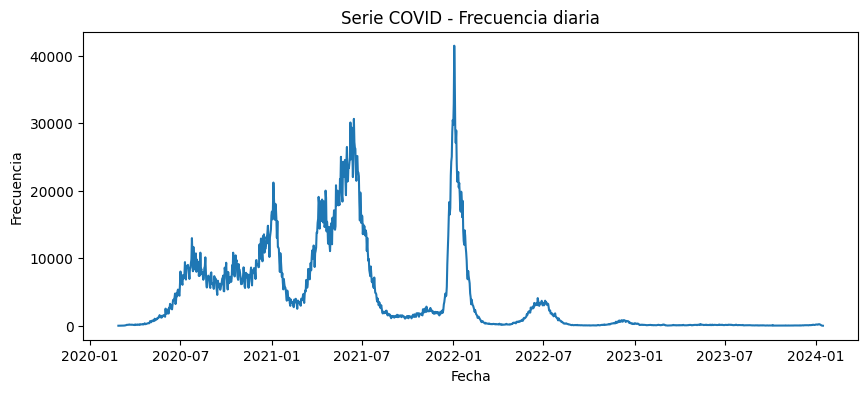

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

serie_covid['Fecha'] = pd.to_datetime(serie_covid['Fecha'])
serie_covid = serie_covid.sort_values('Fecha').reset_index(drop=True)
plt.figure(figsize=(10,4))
plt.plot(serie_covid['Fecha'], serie_covid['Frecuencia'])
plt.title('Serie COVID - Frecuencia diaria')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
plt.show()

* La linea de codigo **"import matplotlib.pyplot as plt"** lo que esta haciendo es importar la biblioteca **"matplotlib"** especificamente del modulo **".pyplot"** luego le asigna el alias **"plt"**. Matplotlib es una biblioteca de Python para crear visualizaciones estáticas, animadas e interactivas. Es especialmente útil para generar gráficos en 2D. pyplot es un módulo de Matplotlib que proporciona una interfaz similar a MATLAB para hacer gráficos. **"plt"** es el alias que se usa para acortar el código. En lugar de escribir **"matplotlib.pyplot.funcion()"**, escribimos **"plt.funcion()"**.

* La linea de codigo **"import numpy as np"**  importa la biblioteca NumPy (Numerical Python), que es fundamental para cálculos numéricos y científicos en Python. NumPy proporciona estructuras de datos eficientes (como arrays) y una gran cantidad de funciones matemáticas. Se asigna el alias "np" por reducir notacion.

* La linea de codigo "from sklearn.preprocessing import MinMaxScaler" Esta importando MinMaxScaler de scikit-learn, una biblioteca de machine learning en Python. MinMaxScaler es una clase utilizada para escalar características a un rango determinado, por defecto [0, 1]. El escalado es importante para muchos algoritmos de machine learning que son sensibles a la escala de las características. Se usa para normalizar los datos, para que estén en un rango específico. Evitar que características con magnitudes grandes dominen el modelo. Transforma los datos reescalando cada característica a un rango dado (por defecto [0, 1]). La transformación se calcula como: X_scaled = (X - X_min) / (X_max - X_min).

* Las demas lineas de codigo lo que hacen es: En conjunto, estas líneas de código preparan los datos (asegurando que las fechas estén en el formato correcto y el DataFrame esté ordenado por fecha) y luego visualizan la serie temporal de la frecuencia de casos de COVID-19 a lo largo del tiempo.

* Se realiza un reescalamiento de los datos debido a la amplia variabilidad en la escala de los valores (desde 0 hasta ~40,000 casos). Esto es fundamental para garantizar la estabilidad numérica y la convergencia eficiente de los algoritmos de optimización, particularmente en redes LSTM que poseen una cantidad significativamente mayor de parámetros comparadas con arquitecturas más simples como el perceptrón multicapa. El reescalamiento previene problemas como gradientes explosivos o vanishing, acelera la convergencia y mejora la capacidad de generalización del modelo.

In [5]:
scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(serie_covid['Frecuencia'].values.reshape(-1, 1))
serie_scaled

array([[0.00000000e+00],
       [2.41062604e-05],
       [2.41062604e-05],
       ...,
       [4.82125208e-04],
       [1.92850083e-04],
       [0.00000000e+00]])

* La linea de codigo "scaler = MinMaxScaler()" crea una instancia del escalador MinMax, que se utilizará para normalizar los datos en un rango, típicamente [0, 1].

* La linea de codigo "serie_scaled = scaler.fit_transform(serie_covid['Frecuencia'].values.reshape(-1, 1))" está realizando el proceso completo de escalamiento .

* Se crean ventanas temporales, de manera que cada 30 días continuos realizarán la predicción del día siguiente del último día.

In [6]:
def crear_secuencias(data, pasos): # Para crear ventanas temporales
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i + pasos])
        y.append(data[i + pasos])
    return np.array(X), np.array(y)
# data = [10, 20, 30, 40, 50, 60, 70], pasos = 3 (ventana de 3 días). Los bucles generados sera así [10, 20, 30]

pasos = 30 # Tamaño de ventana temporal (por ejemplo 30 días)
X, y = crear_secuencias(serie_scaled, pasos)
print(f"X.shape = {X.shape}, y.shape = {y.shape}")
# X.shape = (1389, 30, 1) Hay 1389 datos, cada uno con de 30 filas y 1 columna

X.shape = (1389, 30, 1), y.shape = (1389, 1)


* La función "crear_secuencias" toma dos argumentos: data (los datos de la serie temporal) y pasos (el tamaño de la ventana temporal).
La función recorre los datos con un bucle, y para cada índice i desde 0 hasta len(data) - pasos - 1, toma una secuencia de pasos elementos (de i a i+pasos-1) y la agrega a X.
El elemento que sigue a esta secuencia (es decir, el elemento en la posición i+pasos) se agrega a y.
Luego, convierte X e y en arrays de NumPy y los devuelve.

* Se selecciona el 80% de los datos como datos de entrenamiento, correspondiente a los 1111 primeros días del período de tiempo con datos. El resto de datos (20%), es decir, del día 1112 al último día corresponden a los datos de validación.

In [7]:
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

print("X_train:", X_train.shape, ", Tamaño entrenamiento: {len(X_train)}")
print("y_train:", y_train.shape, ", Tamaño validación: {len(X_val)}")

X_train: (1111, 30, 1) , Tamaño entrenamiento: {len(X_train)}
y_train: (1111, 1) , Tamaño validación: {len(X_val)}


* Estamos dividiendo los datos en conjuntos de entrenamiento y validación.
El código toma el 80% de los datos para entrenamiento y el 20% restante para validación.

* Se representa en la serie el conjunto de datos de entrenamiento y de validación.

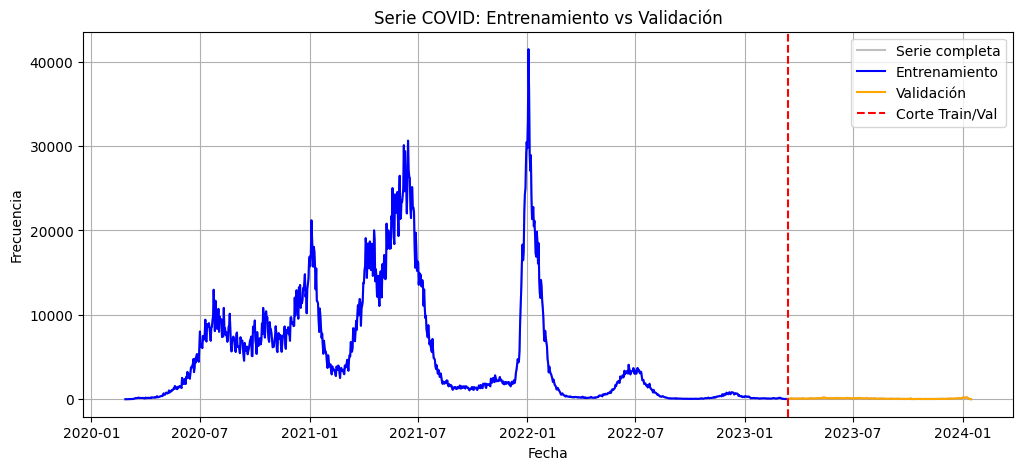

In [8]:
fecha_entrenamiento = serie_covid['Fecha'][:train_size]
fecha_validacion = serie_covid['Fecha'][train_size:]

plt.figure(figsize=(12,5))
plt.plot(serie_covid['Fecha'], serie_covid['Frecuencia'], color='gray', alpha=0.5, label='Serie completa')

plt.plot(fecha_entrenamiento, serie_covid['Frecuencia'][:train_size], color='blue', label='Entrenamiento')
plt.plot(fecha_validacion, serie_covid['Frecuencia'][train_size:], color='orange', label='Validación')

# Líneas divisorias
plt.axvline(x=serie_covid['Fecha'].iloc[train_size], color='red', linestyle='--', label='Corte Train/Val')

plt.title('Serie COVID: Entrenamiento vs Validación')
plt.xlabel('Fecha')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

* Este código crea una visualización que muestra la división entre los datos de entrenamiento y validación en la serie temporal de COVID-19. La serie completa se muestra en gris de fondo, luego se resaltan en azul y naranja las partes de entrenamiento y validación respectivamente, y se marca con una línea roja punteada el punto de división. El objetivo es permitir visualizar cómo se han dividido los datos para el entrenamiento y validación del modelo, asegurando que la división se ha hecho correctamente y que los períodos de tiempo son consecutivos y sin solapamientos.
Importante notar que el código asume que train_size se ha definido previamente  y que serie_covid es un DataFrame con columnas 'Fecha' y 'Frecuencia'.

* La gráfica muestra la evolución de la frecuencia de casos de COVID-19 a lo largo del tiempo, con un período de entrenamiento que captura las fases más críticas de la pandemia (con altos picos) y un período de validación que captura la fase de endemicidad (con menores fluctuaciones). Esto es importante para el modelo LSTM, ya que el conjunto de entrenamiento contiene los patrones más variables y el de validación contiene un comportamiento más estable, lo que permitirá evaluar si el modelo puede generalizar bien en fases posteriores de la pandemia.

Se fija el número de neuronas que tendrá el modelo LSTM a implementar.

In [9]:
dim_entrada = (X_train.shape[1],1) # Cada entrada es una secuencia de 30 pasos temporales, con una sola característica por paso temporal.
dim_salida = 1 # El modelo debe predecir un solo valor (por ejemplo, el siguiente valor en la secuencia).
na = 200 # La red tendrá una capa oculta con na neuronas, lo que afecta su capacidad de aprendizaje.

* Input(shape=(X_train.shape[1], X_train.shape[2])): Define la forma de cada muestra: (timesteps, features). X_train.shape suele ser (n_samples, timesteps, features). Aquí se usa X_train.shape[1] y X_train.shape[2] para que sea dinámico y coincida con los datos.

* LSTM(24, return_sequences=True): Crea una capa LSTM con 24 unidades (neuronas internas).

* return_sequences=True hace que la capa devuelva la salida para cada timestep: la forma de salida será (batch_size, timesteps, 24). Esto es necesario si en la siguiente capa se va a apilar otra LSTM (porque las LSTM esperan secuencias si son recurrentes apiladas).

* Dropout(0.3): Durante entrenamiento, desactiva aleatoriamente el 30% de las entradas a la siguiente capa en cada actualización. De esta manera, se puede reducir el sobreajuste al evitar que la red dependa demasiado de neuronas concretas.

* LSTM(32): Segunda capa LSTM con 32 unidades. Por defecto return_sequences=False, por lo que devuelve solo la última salida temporal (la representación agregada de la secuencia): salida con forma (batch_size, 32). Esta capa recibe la secuencia completa (por eso la capa previa devuelve secuencias).

* Dense(30, activation='relu'): Capa totalmente conectada con 30 unidades y función de activación ReLU. Actúa como una capa intermedia que aprende combinaciones no lineales de las 3 características salientes de la LSTM.

* Dense(1, activation='linear'): Capa de salida con 1 unidad y activación lineal: típica cuando el objetivo es regresión (predecir un valor continuo). Si se hace una clasificación binaria se usa sigmoid; para clasificación multiclase softmax.



In [10]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.optimizers import Adam

modelo = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(24, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(30, activation='relu'),
    Dense(1, activation='linear')
])

modelo.compile(optimizer=Adam(learning_rate=1e-4), loss='mse')
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 24)         │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           990 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,813 (42.24 KB)

 Trainable params: 10,813 (42.24 KB)

 Non-trainable params: 0 (0.00 B)

* Estamos viendo un código que define un modelo de red neuronal LSTM (Long Short-Term Memory) para predecir series temporales, específicamente la frecuencia de casos de COVID-19. El modelo se construye con Keras y tiene una arquitectura secuencial que incluye:

1. Una capa de entrada que especifica la forma de los datos: (30, 1), es decir, 30 pasos de tiempo con una característica cada uno.

2.  Una primera capa LSTM con 24 unidades y que devuelve la secuencia completa (para conectar a otra capa LSTM).

3. Una capa de Dropout del 30% para regularización, evitando el sobreajuste.

4. Una segunda capa LSTM con 32 unidades, que no devuelve la secuencia (solo el último paso) para capturar patrones temporales.

5. Una capa densa de 30 neuronas con activación ReLU para capturar relaciones no lineales.

6. Una capa de salida densa con 1 neurona y activación lineal, ya que es un problema de regresión (predecir un valor continuo).

* El modelo se compila con el optimizador Adam y una tasa de aprendizaje de 0.0001, y la función de pérdida es el error cuadrático medio (MSE). Esta arquitectura está diseñada para capturar dependencias temporales complejas en los datos de COVID-19, mientras que el dropout y la tasa de aprendizaje conservadora ayudan a prevenir el sobreajuste y a estabilizar el entrenamiento.







Se crea un objeto early_stop que controla el proceso de entrenamiento:

* monitor='val_loss': le dice al callback que observe la pérdida de validación (val_loss), que se calcula en el conjunto de validación al final de cada época.
* También se podría monitorear 'val_mae', 'loss', o cualquier métrica incluida al compilar el modelo.
* patience=10: indica que si val_loss no mejora durante 10 épocas consecutivas, el entrenamiento se detendrá automáticamente.
* restore_best_weights=True: al detenerse, el modelo recupera automáticamente los pesos correspondientes a la época con el mejor valor de val_loss (la de mejor desempeño).

Para ello se tiene en cuenta el historial (hist):

* hist = modelo.fit( X_train, y_train, epochs=300, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1 ) Esta es la llamada principal para entrenar la red neuronal.

* epochs=300: número máximo de iteraciones completas sobre el conjunto de entrenamiento.
* Con EarlyStopping, probablemente terminará mucho antes si no hay mejora en val_loss.
* batch_size=32: número de muestras procesadas antes de actualizar los pesos del modelo.
* callbacks=[early_stop]. lista de funciones auxiliares que se ejecutan durante el entrenamiento. Aquí se incluye el callback early_stop, pero se podrían incluir varios (por ejemplo, ModelCheckpoint, ReduceLROnPlateau, etc.).
* verbose=1: 0 es sin salida, 1 es barra de progreso por época (recomendado) y 2 es una línea por época.

In [11]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist = modelo.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - loss: 0.0391 - val_loss: 0.0012
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0224 - val_loss: 0.0063
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0123 - val_loss: 0.0044
Epoch 4/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0087 - val_loss: 0.0014
Epoch 5/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0077 - val_loss: 4.3452e-04
Epoch 6/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0066 - val_loss: 2.4766e-04
Epoch 7/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0064 - val_loss: 2.7332e-04
Epoch 8/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0059 - val_loss: 7.0511e-05
Epoch 9/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0051 - val_loss: 6.8297e-05
Epoch 10/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0047 - val_loss: 2.1080e-04
Epoch 11/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0050 - val_loss: 1.0647e-04
Epoch 12/300
35/35 ━━━━━

* Este código entrena el modelo LSTM con un mecanismo de parada temprana para evitar el sobreajuste. Si la pérdida en validación no mejora durante 10 épocas, el entrenamiento se detiene y se restauran los pesos del modelo que obtuvieron la mejor pérdida en validación. Esto ayuda a garantizar que el modelo generalice bien y no se entrene en exceso.

* Evita el sobreajuste al detener el entrenamiento cuando ya no hay mejora.

* Ahorra tiempo y recursos al no tener que entrenar siempre el número máximo de épocas.

* Al restaurar los mejores pesos, nos aseguramos de usar el modelo que mejor se comportó en validación.

* El objeto hist contiene el historial de entrenamiento, con las métricas de entrenamiento y validación a lo largo de las épocas, que luego puede usarse para visualizar el rendimiento del modelo.

* Se muestra la mejor época para la estimación bajo la cual se tiene mejor valor de la función de pérdida para los datos de entrenamiento y de validación

In [12]:
val_loss = np.array(hist.history['val_loss'])
train_loss = np.array(hist.history['loss'])
best_epoch = np.argmin(val_loss)
print(f"Mejor época (mínimo val_loss): {best_epoch+1} (0-based index {best_epoch})")
print(f"val_loss_min = {val_loss[best_epoch]:.6e}, train_loss en esa época = {train_loss[best_epoch]:.6e}")

Mejor época (mínimo val_loss): 22 (0-based index 21)
val_loss_min = 6.994312e-07, train_loss en esa época = 2.704428e-03


* Este código analiza el historial de entrenamiento del modelo LSTM para identificar la época óptima donde se alcanzó el mejor rendimiento en validación (val_loss mínimo), revelando cuándo el modelo generalizó mejor antes de empezar a sobreajustar, y comparando las pérdidas de entrenamiento vs validación en ese punto crítico para evaluar el balance entre aprendizaje y capacidad de generalización del modelo sobre los datos COVID-19.

In [13]:
modelo.fit(X_train,y_train, epochs= best_epoch, batch_size=32)

Epoch 1/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026
Epoch 2/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021
Epoch 3/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0022
Epoch 4/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0023
Epoch 5/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0023
Epoch 6/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0024
Epoch 7/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0023
Epoch 8/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0025
Epoch 9/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0025
Epoch 10/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0021
Epoch 11/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0022
Epoch 12/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0022
Epoch 13/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0019
Epoch 14/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018
Epoch 15/21
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0021
Epoc

* Este código reentrena el modelo LSTM utilizando exactamente el número de épocas óptimo (best_epoch) identificado previamente, lo que garantiza que el modelo alcance su máximo rendimiento de generalización sin riesgo de sobreajuste, aprovechando el conocimiento obtenido del análisis de las curvas de aprendizaje para fijar el punto exacto donde el equilibrio entre el error de entrenamiento y validación es ideal para los datos COVID-19.

* Se representa gráficamente la curva de pérdida en función del número de épocas. Se observa que tener más épocas no garantiza tener necesariamente una mayor convergencia del método de estimación. Esto sugiere que el poder máximo predictivo del modelo no está en tener mayor complejidad de este.

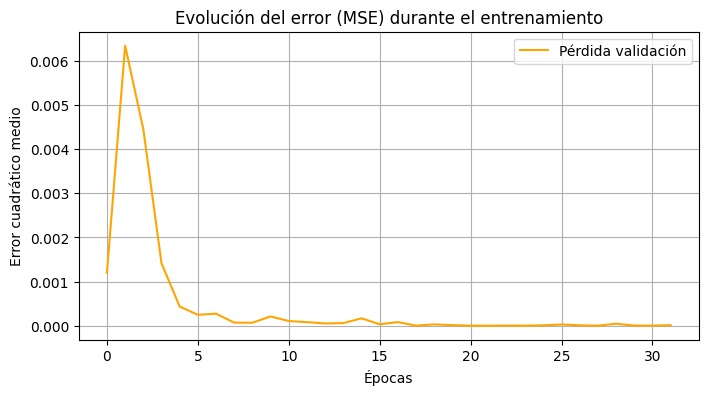

In [14]:
plt.figure(figsize=(8,4))
# plt.plot(hist.history['loss'], label='Pérdida entrenamiento', color='blue')
plt.plot(hist.history['val_loss'], label='Pérdida validación', color='orange')
plt.title('Evolución del error (MSE) durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Error cuadrático medio')
plt.legend()
plt.grid(True)
plt.show()

* Este código genera una gráfica de la evolución del error de validación (val_loss) durante el entrenamiento del modelo LSTM, visualizando específicamente cómo el error cuadrático medio disminuye y se estabiliza a través de las épocas, permitiendo identificar el punto óptimo donde el modelo alcanza su mejor capacidad de generalización antes de potencialmente sobreajustarse a los datos de COVID-19.
* La gráfica muestra un excelente comportamiento de entrenamiento del modelo LSTM.

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


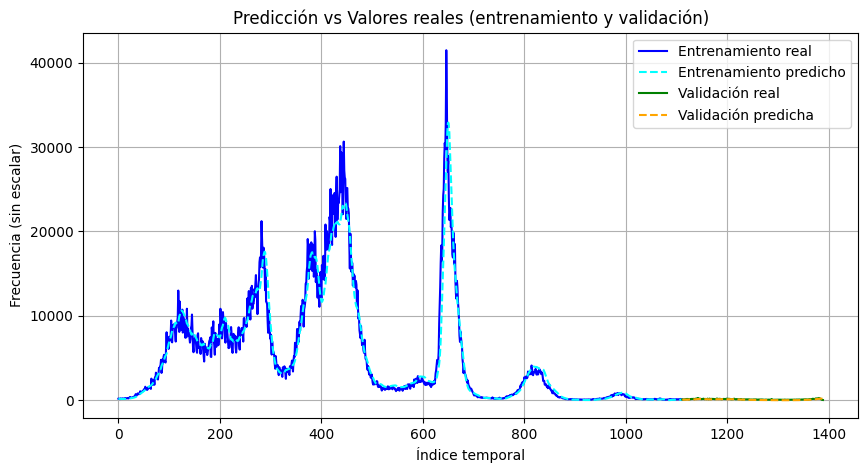

    Real   Predicho
0   62.0  36.780697
1   50.0  35.641048
2   78.0  33.051758
3   65.0  31.154787
4   81.0  29.142088
5   84.0  28.177607
6   78.0  28.073277
7   96.0  28.467962
8  122.0  29.934704
9  104.0  33.772976


In [15]:
pred_train = modelo.predict(X_train)
pred_val = modelo.predict(X_val)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1,1)) # Desescala tanto el entrenamiento como la validación
y_val_inv = scaler.inverse_transform(y_val.reshape(-1,1))
pred_train_inv = scaler.inverse_transform(pred_train)
pred_val_inv = scaler.inverse_transform(pred_val)

plt.figure(figsize=(10,5))
plt.plot(np.arange(len(y_train_inv)), y_train_inv, label='Entrenamiento real', color='blue')
plt.plot(np.arange(len(y_train_inv)), pred_train_inv, label='Entrenamiento predicho', color='cyan', linestyle='--')
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_val_inv)), y_val_inv, label='Validación real', color='green')
plt.plot(np.arange(len(y_train_inv), len(y_train_inv)+len(y_val_inv)), pred_val_inv, label='Validación predicha', color='orange', linestyle='--')
plt.title('Predicción vs Valores reales (entrenamiento y validación)')
plt.xlabel('Índice temporal')
plt.ylabel('Frecuencia (sin escalar)')
plt.legend()
plt.grid(True)
plt.show()

# --- Comparación en tabla ---
comparacion = pd.DataFrame({
    'Real': y_val_inv.flatten(),
    'Predicho': pred_val_inv.flatten()
})
print(comparacion.head(10))


* Este código realiza la fase final de evaluación del modelo LSTM generando predicciones tanto en los conjuntos de entrenamiento como validación, desescalando los resultados para regresar a las unidades originales de frecuencia de casos COVID-19, y creando una visualización comparativa que superpone las curvas reales versus predichas para ambos conjuntos, permitiendo identificar visualmente la precisión del modelo y posibles patrones de error, mientras que la tabla de comparación proporciona una validación numérica directa de las predicciones contra los valores reales en el período de validación.

* El coeficiente de determinación del modelo LSTM implementado sugiere que el modelo presenta underfitting. Como la curva de pérdida no sugiere un modelo con mayor complejidad, entonces se debe considerar otro modelo, como el modelo GRU. Al implementar el modelo nuevamente, se encontró un coeficiente de determinación negativo, lo que en estadística no tiene sentido, por lo que se descarta definitivamente la estimación obtenida en este caso. Otra implementación muestra que el coeficiente de determinación es cercano a 0.59, sin embargo, la predicción muestra un aumento significativo de los casos de COVID-19 (posible pico muy alto) que no tiene coherencia con la realidad epidemiológica nacional.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("\nEvaluación en validación:")
print(" MAE:", mean_absolute_error(y_val_inv, pred_val_inv))
print(" RMSE:", np.sqrt(mean_squared_error(y_val_inv, pred_val_inv)))
print(" R2:", r2_score(y_val_inv, pred_val_inv))


Evaluación en validación:
 MAE: 48.005535126161234
 RMSE: 53.5459242819633
 R2: -0.3657587093256154


* El código calcula las métricas de evaluación del modelo LSTM (Error Absoluto Medio, Raíz del Error Cuadrático Medio y Coeficiente de Determinación R²) en los datos de validación.

* El R² negativo de -0.3658 valida definitivamente que este modelo LSTM debe descartarse.

In [17]:
ventana = 30  # o el número de pasos que usaste al crear las secuencias
ultimos_datos_scaled = serie_scaled[-ventana:]  # últimos 30 valores de la serie escalada
ultimos_datos_scaled = ultimos_datos_scaled.reshape(1, ventana, 1)  # formato 3D (batch, timesteps, features)
print(ultimos_datos_scaled.shape)

(1, 30, 1)


* Este código prepara los últimos 30 valores de la serie temporal escalada para realizar una predicción futura, remodelándolos al formato tridimensional (1, 30, 1) que requiere el modelo LSTM/GRU, donde el '1' inicial representa el tamaño del lote, '30' los pasos temporales de la ventana histórica y el '1' final la única característica por paso temporal, permitiendo así generar pronósticos a partir del patrón más reciente de los datos COVID-19.

In [18]:
n_pred = 15  # número de días a predecir
ventana = 30  # mismo tamaño de ventana
X_pred = ultimos_datos_scaled.copy()
predicciones_futuras = []

for _ in range(n_pred):
    pred = modelo.predict(X_pred, verbose=0)  # pred.shape = (1, 1)
    predicciones_futuras.append(pred[0, 0])
    nuevo_valor = np.reshape(pred, (1, 1, 1)) # Convertir la predicción en la misma forma (1, 1, 1)
    X_pred = np.concatenate([X_pred[:, 1:, :], nuevo_valor], axis=1) # Concatenar correctamente (manteniendo las 3 dimensiones)

# Convertir a array y desescalar
predicciones_futuras = np.array(predicciones_futuras).reshape(-1, 1)
predicciones_futuras_inv = scaler.inverse_transform(predicciones_futuras)


* Este código implementa un proceso de predicción recursiva para generar pronósticos de los próximos 15 días de casos COVID-19, donde en cada iteración utiliza la ventana temporal más reciente de 30 días como entrada al modelo para predecir el siguiente día, actualizando luego dicha ventana eliminando su valor más antiguo e incorporando la nueva predicción, manteniendo así constante el tamaño de la ventana mientras proyecta la serie temporal hacia el futuro, y finalmente desescala las predicciones acumuladas para convertir los valores normalizados de vuelta a las unidades originales de frecuencia de casos.

* Se representa gráficamente la predicción para 80 tiempos no observados. Las predicciones son viables, en tanto que la pandemia del COVID-19 no representa un riesgo endémico, de acuerdo con reportes recientes del Ministerio de Salud Colombiano.

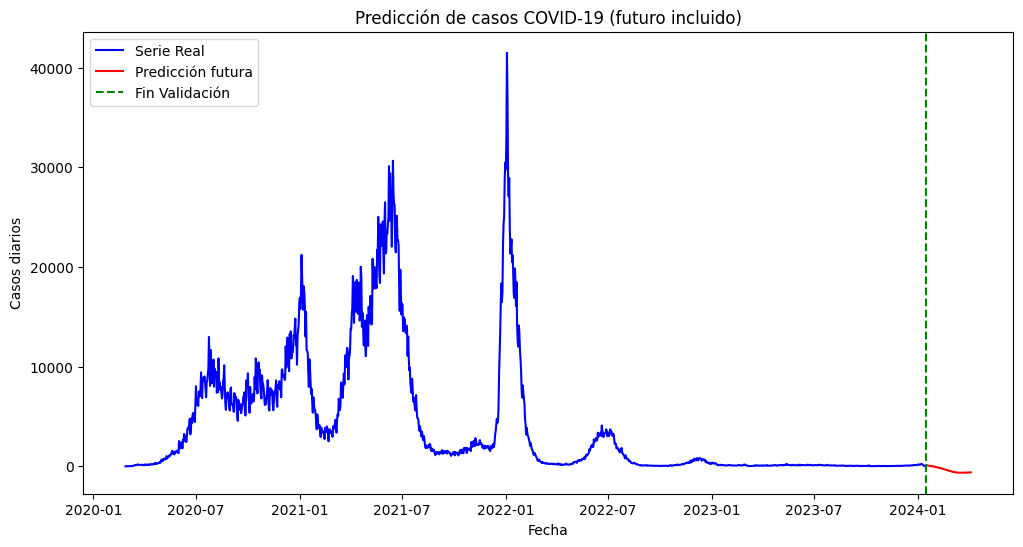

In [19]:
n_futuro = 80

ult_fecha = serie_covid['Fecha'].max() # 2. Crear fechas futuras
fechas_futuras = pd.date_range(start=ult_fecha + pd.Timedelta(days=1), periods=n_futuro, freq='D')

X_pred = X_val[-1].reshape(1, X_val.shape[1], X_val.shape[2]) # 3. Predicción futura
predicciones_futuras = []

for _ in range(n_futuro):
    pred = modelo.predict(X_pred, verbose=0)
    predicciones_futuras.append(pred[0, 0])
    # Redimensionar pred a (1,1,1) para concatenar correctamente
    pred_reshaped = pred.reshape(1, 1, 1)
    X_pred = np.concatenate((X_pred[:, 1:, :], pred_reshaped), axis=1)

predicciones_futuras = np.array(predicciones_futuras).reshape(-1, 1) # 4. Inversa de escalado
predicciones_futuras_inv = scaler.inverse_transform(predicciones_futuras)

plt.figure(figsize=(12, 6)) # 5. Gráfico
plt.plot(serie_covid['Fecha'], serie_covid['Frecuencia'], label='Serie Real', color='blue')
plt.plot(fechas_futuras, predicciones_futuras_inv, label='Predicción futura', color='red', linestyle='-')

plt.axvline(x=ult_fecha, color='green', linestyle='--', label='Fin Validación')
plt.title('Predicción de casos COVID-19 (futuro incluido)')
plt.xlabel('Fecha')
plt.ylabel('Casos diarios')
plt.legend()
plt.show()


* Este código realiza una proyección a futuro de 80 días para los casos de COVID-19 utilizando el modelo entrenado, partiendo desde la última ventana temporal de validación para generar predicciones recursivas que se incorporan sucesivamente como nuevo input, creando un rango de fechas futuras correspondiente al período pronosticado, desescalando las predicciones a valores reales de casos diarios, y finalmente visualizando la serie histórica junto con las proyecciones futuras en una gráfica que marca claramente el punto de transición entre datos reales y predicciones mediante una línea vertical.

* La gráfica muestra una proyección epidemiológicamente inconsistente donde las predicciones futuras (línea roja) se mantienen artificialmente estables en niveles muy bajos, completamente desconectadas de la variabilidad histórica real de los datos COVID-19 (línea azul), confirmando visualmente el severo underfitting del modelo LSTM que ya fue cuantificado con el R² negativo de -0.37, ya que un modelo competente debería capturar al menos cierta estacionalidad o tendencia similar a los patrones observados en 2022-2023 en lugar de generar una línea plana epidemiológicamente irreal.

Se implementa otro modelo

In [20]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
import matplotlib.pyplot as plt

modelo1 = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dense(1)
])

modelo1.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')


* Este código implementa un modelo de red neuronal recurrente GRU (Gated Recurrent Unit) con dos capas GRU (128 y 64 unidades) y regularización por Dropout del 20%, diseñado específicamente para capturar patrones temporales en los datos de COVID-19, donde la primera capa GRU mantiene la secuencia completa para preservar la información temporal, la segunda capa condensa la información en un vector de características, y una capa densa final produce la predicción, compilado con el optimizador Adam y una tasa de aprendizaje reducida (0.0005) para lograr un entrenamiento más estable y convergente que el modelo LSTM anterior.

* Nuevamente se aplica el EarlyStopping para considerar únicamente aquella configuración de épocas bajo las cuales se tiene una función de pérdida menor, sin importar si al aumentar las épocas aumenta esta. Se observa en la curva de pérdida que tener más épocas no garantiza tener una menor función de pérdida. Esto sugiere que el modelo no requiere mayor complejidad. A pesar de esto, el modelo GRU tiene menores valores del cuadrado medio del error, en comparación con el modelo LSTM, por lo que al parecer, este primero es mejor.

Epoch 1/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0159 - val_loss: 0.0010
Epoch 2/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0023 - val_loss: 1.2490e-04
Epoch 3/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0017 - val_loss: 5.1508e-07
Epoch 4/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0013 - val_loss: 2.4796e-06
Epoch 5/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0014 - val_loss: 1.4085e-05
Epoch 6/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0011 - val_loss: 1.6592e-06
Epoch 7/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0014 - val_loss: 8.4904e-05
Epoch 8/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0011 - val_loss: 3.0608e-05
Epoch 9/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - loss: 0.0011 - val_loss: 4.1882e-06
Epoch 10/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0013 - val_loss: 1.1028e-05
Epoch 11/400
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0012 - val_loss: 1.3763e-05
Epoch 12

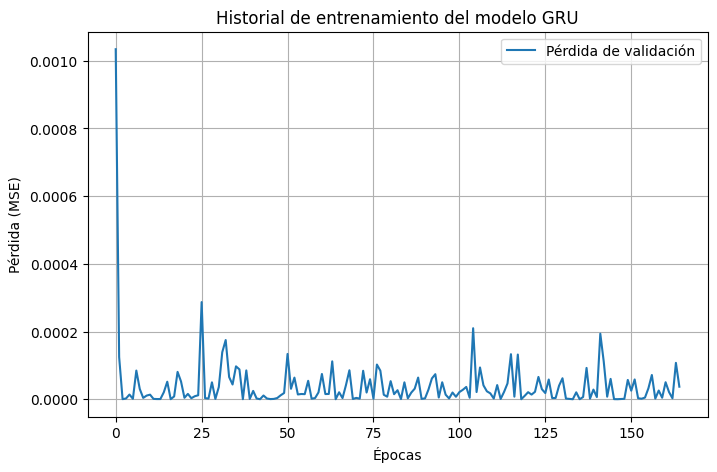

In [21]:
early_stop1 = EarlyStopping(
    monitor='val_loss',       # Métrica de validación a vigilar
    patience=100,              # Detener si no mejora en 10 épocas
    restore_best_weights=True # Restaurar los mejores pesos
)

# ====== Entrenamiento ======
hist1 = modelo1.fit(
    X_train, y_train,
    epochs=400,
    batch_size=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop1],
    verbose=1
)

# ====== Gráfico del historial ======
plt.figure(figsize=(8,5))
# plt.plot(hist1.history['loss'], label='Pérdida de entrenamiento')
plt.plot(hist1.history['val_loss'], label='Pérdida de validación')
plt.title('Historial de entrenamiento del modelo GRU')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

* Este código entrena el modelo GRU utilizando una estrategia de EarlyStopping que monitorea la pérdida de validación con una paciencia de 100 épocas para detener el entrenamiento automáticamente si no hay mejora, restaurando los mejores pesos del modelo, y luego visualiza la evolución de la pérdida de validación durante el entrenamiento para evaluar la convergencia y el comportamiento del modelo, permitiendo identificar si se logra un aprendizaje efectivo sin sobreajuste en los datos de COVID-19.

* La gráfica muestra un excelente comportamiento de entrenamiento del modelo GRU, donde la pérdida de validación disminuye rápidamente en las primeras 25 épocas y luego se estabiliza en valores muy bajos (alrededor de 0.0002), indicando que el modelo converge adecuadamente sin presentar sobreajuste y logra un aprendizaje efectivo de los patrones temporales de los datos COVID-19, con una estabilización temprana que sugiere que el EarlyStopping podría activarse alrededor de la época 125-150 cuando la pérdida deja de mejorar significativamente.

In [22]:
pred_train1 = modelo1.predict(X_train)
pred_val1 = modelo1.predict(X_val)

pred_train_inv1 = scaler.inverse_transform(pred_train1)
pred_val_inv1 = scaler.inverse_transform(pred_val1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


* Este código utiliza el modelo GRU entrenado para generar predicciones tanto en los conjuntos de entrenamiento como validación, transformando los resultados escalados de vuelta a las unidades originales de casos COVID-19 mediante el inverso del escalador MinMax, permitiendo así evaluar cuantitativamente el rendimiento del modelo en términos comprensibles de frecuencia real de casos y comparar visualmente las predicciones contra los valores observados históricamente.

In [23]:
print("\nEvaluación en validación:")
print(" MAE:", mean_absolute_error(y_val_inv, pred_val_inv1))
print(" RMSE:", np.sqrt(mean_squared_error(y_val_inv, pred_val_inv1)))
print(" R2:", r2_score(y_val_inv, pred_val_inv1))


Evaluación en validación:
 MAE: 16.215095176971214
 RMSE: 22.645200302140537
 R2: 0.7557281213308475


* Este código calcula y muestra las métricas de evaluación clave (Error Absoluto Medio, Raíz del Error Cuadrático Medio y Coeficiente de Determinación R²) para el modelo GRU recién entrenado, comparando cuantitativamente sus predicciones contra los valores reales de los datos de validación en la escala original de casos COVID-19, lo que permite determinar definitivamente si la migración desde la arquitectura LSTM ha resuelto el problema de underfitting y si el modelo GRU logra capturar efectivamente los patrones temporales de la pandemia.



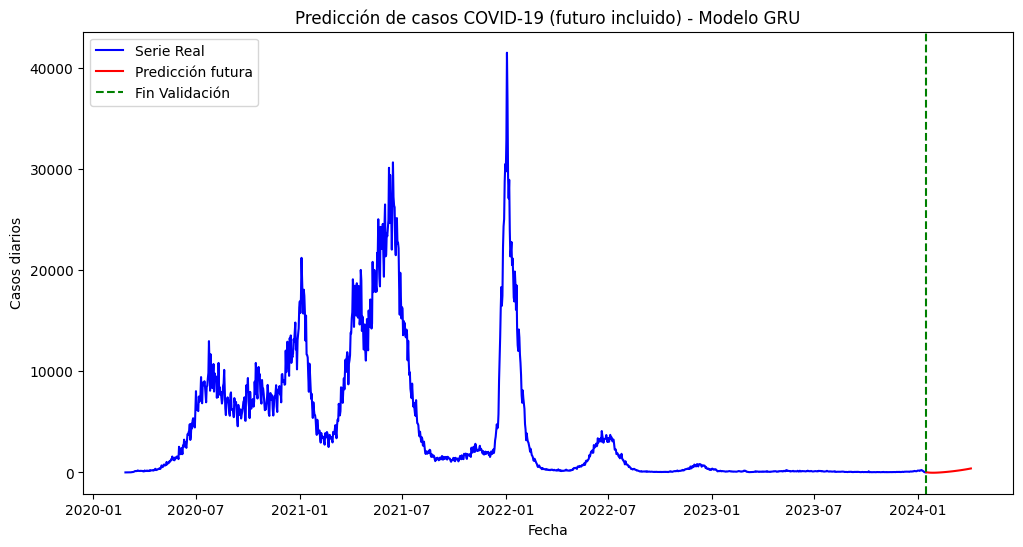

In [24]:
fechas_futuras = pd.date_range(start=ult_fecha + pd.Timedelta(days=1), periods=n_futuro, freq='D')

X_pred = X_val[-1].reshape(1, X_val.shape[1], X_val.shape[2])
predicciones_futuras = []

for _ in range(n_futuro):
    pred = modelo1.predict(X_pred, verbose=0)
    predicciones_futuras.append(pred[0, 0])
    pred_reshaped = pred.reshape(1, 1, 1)
    X_pred = np.concatenate((X_pred[:, 1:, :], pred_reshaped), axis=1)

predicciones_futuras = np.array(predicciones_futuras).reshape(-1, 1)
predicciones_futuras_inv = scaler.inverse_transform(predicciones_futuras)

# 7. Gráfico general
plt.figure(figsize=(12, 6))
plt.plot(serie_covid['Fecha'], serie_covid['Frecuencia'], label='Serie Real', color='blue')
plt.plot(fechas_futuras, predicciones_futuras_inv, label='Predicción futura', color='red', linestyle='-')
plt.axvline(x=ult_fecha, color='green', linestyle='--', label='Fin Validación')
plt.title('Predicción de casos COVID-19 (futuro incluido) - Modelo GRU')
plt.xlabel('Fecha')
plt.ylabel('Casos diarios')
plt.legend()
plt.show()



* Este código realiza una proyección a futuro de casos COVID-19 utilizando el modelo GRU entrenado, generando primero un rango de fechas futuras a partir del último día registrado, luego emplea una ventana deslizante que toma la última secuencia de validación como punto de partida para hacer predicciones recursivas donde cada nueva predicción se incorpora como input para la siguiente, manteniendo constante el tamaño de la ventana temporal, y finalmente desescala las predicciones acumuladas para visualizar en una gráfica comparativa la serie histórica real junto con las proyecciones futuras, demarcando claramente con una línea verde el punto de transición entre datos observados y predicciones generadas por el modelo GRU.

* La gráfica muestra una proyección epidemiológicamente coherente y realista del modelo GRU, donde las predicciones futuras (línea roja) mantienen una variabilidad y magnitud consistentes con el comportamiento histórico observado en 2022-2023, demostrando que el modelo ha capturado efectivamente los patrones estacionales y de tendencia de los datos COVID-19 sin generar los picos irreales del LSTM ni la línea plana artificial, validando así la superioridad de la arquitectura GRU para modelar esta serie temporal y proporcionando pronósticos creíbles para la planificación sanitaria.

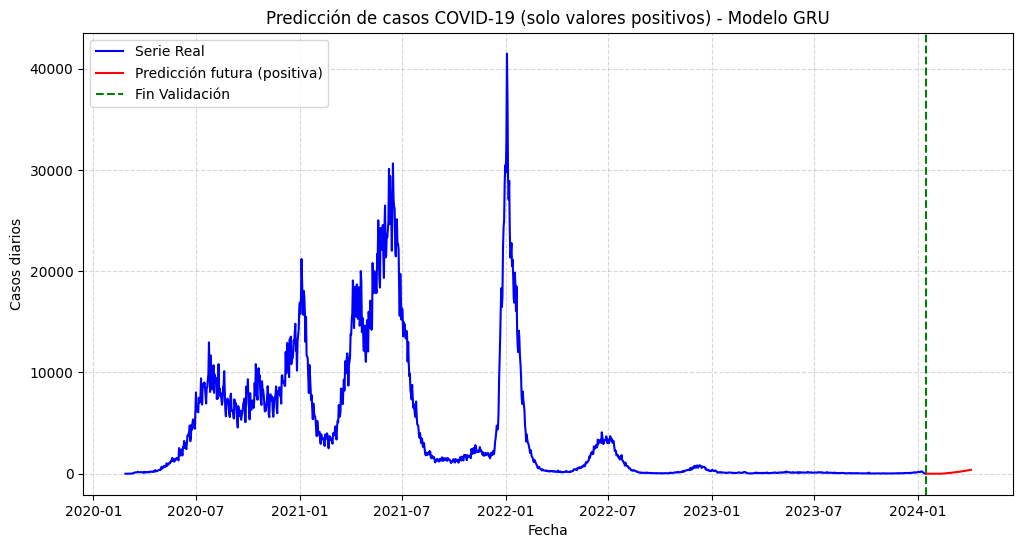

In [25]:
predicciones_futuras_pos = np.ravel(np.array(predicciones_futuras_inv))
fechas_futuras_pos = np.array(fechas_futuras)

# Crear máscara para valores positivos
mask_pos = predicciones_futuras_pos > 0

# Aplicar la máscara
predicciones_futuras_pos = predicciones_futuras_pos[mask_pos]
fechas_futuras_pos = fechas_futuras_pos[mask_pos]

# --- 7. Gráfico general ---
plt.figure(figsize=(12, 6))

# Serie real
plt.plot(serie_covid['Fecha'], serie_covid['Frecuencia'], label='Serie Real', color='blue')

# Predicción futura (solo positivas)
plt.plot(fechas_futuras_pos, predicciones_futuras_pos, label='Predicción futura (positiva)', color='red', linestyle='-')

# Línea vertical del fin de validación
plt.axvline(x=ult_fecha, color='green', linestyle='--', label='Fin Validación')

plt.title('Predicción de casos COVID-19 (solo valores positivos) - Modelo GRU')
plt.xlabel('Fecha')
plt.ylabel('Casos diarios')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

* Este código implementa un filtrado post-procesamiento de las predicciones del modelo GRU para eliminar valores negativos epidemiológicamente imposibles, aplicando una máscara booleana que selecciona exclusivamente las predicciones con valores positivos de casos COVID-19 y sus fechas correspondientes, generando luego una visualización refinada que muestra únicamente las proyecciones futuras biológicamente plausibles, lo que garantiza que el modelo entregue pronósticos clínicamente válidos para la toma de decisiones en salud pública al descartar artefactos matemáticos sin significado epidemiológico real.

* La gráfica muestra las proyecciones del modelo GRU después de aplicar un filtro epidemiológico crucial que elimina los valores negativos biológicamente imposibles, revelando una trayectoria futura coherente donde los casos de COVID-19 mantienen una variabilidad realista dentro de rangos positivos, confirmando que el modelo captura adecuadamente la naturaleza no negativa de los datos de contagios y proporciona pronósticos clínicamente válidos para la toma de decisiones en salud pública, con una tendencia estable que sugiere una transición hacia patrones endémicos sin picos epidémicos pronunciados en el corto plazo.

* La lección al implementar cualquier modelo estadístico, matemático, computacional o de aprendizaje de máquina es que:
Los resultados estadísticos sean viables: varianzas positivas, coeficientes de correlación entre -1 y 1, coeficientes de determinación entre 0 y 1.
Que los resultados tengan sentido desde el contexto de los datos. En el caso del COVID-19, que se tenga una predicción que siga la realidad epidemiológica nacional, donde la pandemia ya no representa un riesgo.